# Week 4 — Supervised & Unsupervised Learning
### Phase 2: Intro to ML / DL

**Topics covered:**
1. Supervised learning — concept, math, and reasoning
2. Unsupervised learning — concept, math, and reasoning
3. Train / test split and why we need it
4. Evaluation metrics — classification and regression
5. **Project:** Iris & Titanic dataset exploration

Every section below pairs a plain-language explanation with the underlying math, a runnable
example, and a real-world case where the idea actually gets used. The goal isn't just to
run `.fit()` — it's to understand *why* each step exists, so that when a model misbehaves later
in the course, you know which assumption to question first.

## 0. Setup

We'll use `numpy`/`pandas` for data handling, `matplotlib`/`seaborn` for visualization, and
`scikit-learn` for models and metrics — the standard stack introduced in the Phase 2 prerequisites.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
np.random.seed(42)  # reproducibility: same "random" split every run


---
## 1. Supervised Learning

### 1.1 The idea

In supervised learning, every training example is a pair $(x_i, y_i)$: a feature vector
$x_i$ and the *correct answer* $y_i$. The algorithm's job is to learn a function
$f$ that maps new inputs to accurate predictions.

**Why "supervised"?** Because a "supervisor" (historical data, human labelling, a logged
outcome) has already told us the right answer for every training example. The model isn't
inventing categories — it's learning to reproduce a labelling process that already happened.

### 1.2 The math: what "learning" actually optimises

We choose $f$ from a family of functions parameterised by $\theta$ (e.g. the weights of a
linear model), and we search for the $\theta$ that minimises **average loss** across the
training set:

$$
\hat{\theta} = \arg\min_{\theta} \; \frac{1}{n}\sum_{i=1}^{n} L\big(y_i,\, f_\theta(x_i)\big)
$$

- $L$ is a **loss function** — it scores how wrong a single prediction is.
  - Classification often uses **cross-entropy loss** (penalises confident wrong answers heavily).
  - Regression often uses **squared error**: $L(y, \hat y) = (y - \hat y)^2$.
- $n$ is the number of training examples.
- The $\arg\min$ says: search over possible parameter values and keep the ones that make
  the total error as small as possible.

**Reasoning — why frame it this way?** Turning "learn a good model" into "minimise a
mathematical function" is what lets us use calculus. Once we have a differentiable loss, we
can compute gradients and use optimisation algorithms (like gradient descent) to *automatically*
improve the model, instead of hand-tuning parameters by trial and error. This single idea —
loss minimisation — is the backbone of everything from linear regression to deep neural networks.

### 1.3 Real-world example

A bank wants to predict loan default. Every historical loan is a labelled example:
$x$ = (income, credit score, loan amount, employment length...), $y$ = did they default
(1) or not (0). The bank trains a model to minimise prediction error on this historical
record, then uses it to score *new* applicants who don't have a known outcome yet.

### 1.4 Two flavours: classification vs. regression

| | **Classification** | **Regression** |
|---|---|---|
| Target $y$ | Discrete category | Continuous number |
| Example | Iris species, spam/not-spam | House price, temperature |
| Typical loss | Cross-entropy | Squared error |
| Output | Class label / probability | Real number |

Let's work with the **Iris dataset** — a classic classification problem: predict the species
of a flower from four physical measurements.

In [ ]:
iris = load_iris(as_frame=True)
df_iris = iris.frame.copy()
df_iris["species"] = df_iris["target"].map(dict(enumerate(iris.target_names)))
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
df_iris.describe().T


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5
target,150.0,1.000000,0.819232,0.0,0.0,1.00,2.0,2.0


**Reasoning — always look before you model.** `describe()` and a quick visual check catch
issues early: are features on wildly different scales? Are classes balanced? Iris is a clean
teaching dataset (150 rows, 50 per class, no missing values) — real datasets rarely are, which
is exactly why we practice on Titanic later in this notebook.

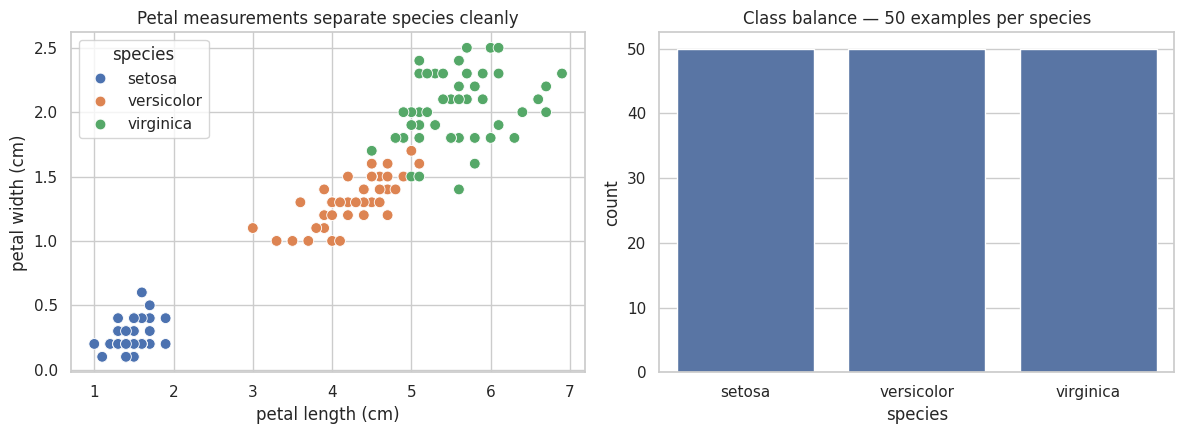

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.scatterplot(data=df_iris, x="petal length (cm)", y="petal width (cm)",
                 hue="species", ax=axes[0], s=60)
axes[0].set_title("Petal measurements separate species cleanly")

sns.countplot(data=df_iris, x="species", ax=axes[1])
axes[1].set_title("Class balance — 50 examples per species")

plt.tight_layout()
plt.show()


Notice how well petal length/width separate the three species visually. This matters:
if the classes were *not* visually separable in any feature combination, no amount of clever
modelling would rescue us — the signal simply might not be there. Exploratory plots like this
tell you whether the problem is learnable before you invest in a model.

---
## 2. Train / Test Split

### 2.1 Why we hide data from the model

If we evaluate a model on the same data it trained on, a high score just proves the model
can **memorise** — not that it can **generalise** to new, unseen data. We need a fair test.

### 2.2 The math — generalisation gap

$$
\text{Gap} = \text{Error}_{\text{test}} - \text{Error}_{\text{train}}
$$

- **Small gap** → the model generalises well.
- **Large gap** → **overfitting** (high variance): the model has fit noise specific to the
  training set rather than the true underlying pattern.
- **High error on both** → **underfitting** (high bias): the model is too simple to capture
  the pattern at all.

This is the classical **bias–variance tradeoff**: total expected error can be decomposed as

$$
\mathbb{E}[(y-\hat f(x))^2] = \underbrace{\big(\text{Bias}[\hat f(x)]\big)^2}_{\text{too simple}} + \underbrace{\text{Var}[\hat f(x)]}_{\text{too sensitive to training data}} + \underbrace{\sigma^2}_{\text{irreducible noise}}
$$

**Reasoning:** a model that's too simple (e.g. a straight line through curved data) has high
bias — it's *systematically* wrong. A model that's too flexible (e.g. memorising every
training point) has high variance — it changes wildly depending on which data it happened to
see. The train/test split is our primary tool for **detecting** which regime we're in.

In [5]:
X = df_iris[iris.feature_names]
y = df_iris["target"]

# stratify=y keeps the class proportions identical in both splits —
# without it, a small/unlucky split could leave a class underrepresented in the test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} rows  |  Test size: {X_test.shape[0]} rows")
print("\nClass balance in train:\n", y_train.value_counts(normalize=True).round(2))
print("\nClass balance in test:\n", y_test.value_counts(normalize=True).round(2))


Train size: 120 rows  |  Test size: 30 rows

Class balance in train:
 target
0    0.33
2    0.33
1    0.33
Name: proportion, dtype: float64

Class balance in test:
 target
0    0.33
2    0.33
1    0.33
Name: proportion, dtype: float64


### 2.3 A more robust estimate — k-fold cross-validation

A single 80/20 split can be lucky or unlucky depending on which rows land in the test set.
**k-fold cross-validation** splits the data into $k$ equal folds, trains $k$ times (holding out
a different fold each time), and averages the result:

$$
\text{CV score} = \frac{1}{k}\sum_{k=1}^{K} \text{Error}(\text{fold}_k)
$$

Every row gets to be in the test set exactly once, so the final estimate depends far less on
one particular split — at the cost of $k\times$ the compute.

In [6]:
model_cv = LogisticRegression(max_iter=200)
cv_scores = cross_val_score(model_cv, X, y, cv=5, scoring="accuracy")

print("Accuracy per fold:", np.round(cv_scores, 3))
print(f"Mean CV accuracy: {cv_scores.mean():.3f}  (+/- {cv_scores.std():.3f})")


Accuracy per fold: [0.967 1.    0.933 0.967 1.   ]
Mean CV accuracy: 0.973  (+/- 0.025)


---
## 3. Fitting a Baseline Classifier

We'll train **Logistic Regression** — despite the name, a classification algorithm. It models
the probability of each class using the *logistic (sigmoid) function*:

$$
P(y=1 \mid x) = \sigma(\theta^\top x) = \frac{1}{1 + e^{-\theta^\top x}}
$$

The sigmoid squashes any real number into $(0, 1)$, so its output can be read as a probability.
Training minimises cross-entropy loss (a direct instance of the loss-minimisation framework
from Section 1).

In [7]:
clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)

print("First 5 predictions: ", y_pred[:5])
print("First 5 true labels: ", y_test.values[:5])


First 5 predictions:  [0 2 1 1 0]
First 5 true labels:  [0 2 1 1 0]


---
## 4. Evaluation Metrics — Classification

### 4.1 Confusion matrix

The confusion matrix is the foundation every classification metric is built from:

| | Predicted + | Predicted − |
|---|---|---|
| **Actual +** | True Positive (TP) | False Negative (FN) |
| **Actual −** | False Positive (FP) | True Negative (TN) |

### 4.2 Formulas

$$
\text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN}
\qquad
\text{Precision} = \frac{TP}{TP+FP}
\qquad
\text{Recall} = \frac{TP}{TP+FN}
\qquad
F_1 = 2\cdot\frac{\text{Precision}\cdot\text{Recall}}{\text{Precision}+\text{Recall}}
$$

**Reasoning — why not just accuracy?** Accuracy treats every class equally, which breaks down
on imbalanced data. If 95% of transactions are legitimate, a model that predicts "legitimate"
every single time scores 95% accuracy while catching zero fraud. Precision and recall isolate
the two ways a model can be wrong:
- **Precision** answers: *of everything I flagged as positive, how much was actually positive?*
  Low precision = too many false alarms.
- **Recall** answers: *of everything that was actually positive, how much did I catch?*
  Low recall = missed cases.

Which one matters more is a **business decision**, not a math one — a spam filter favours
precision (don't bury real email), a cancer screening test favours recall (don't miss a
real case).

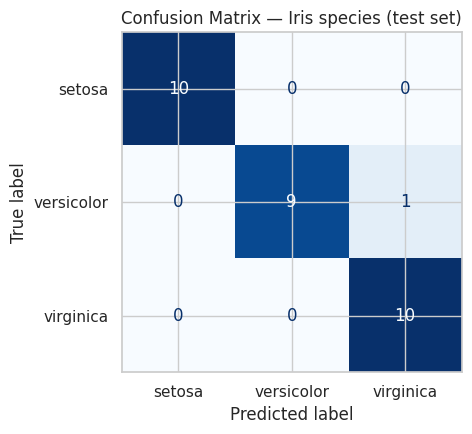

In [8]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)

fig, ax = plt.subplots(figsize=(5, 4.5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix — Iris species (test set)")
plt.tight_layout()
plt.show()


In [9]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}  (macro-averaged across 3 classes)")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=iris.target_names))


Accuracy : 0.967
Precision: 0.970  (macro-averaged across 3 classes)
Recall   : 0.967
F1-score : 0.967

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



**Note on `average="macro"`:** with more than two classes there's no single TP/FP/FN —
scikit-learn computes precision/recall per class and averages. `macro` weighs every class
equally regardless of size; `weighted` weighs by how many true examples each class has. Choose
`macro` when every class matters equally (as with balanced Iris); choose `weighted` when
larger classes should dominate the score.

---
## 5. Evaluation Metrics — Regression

Iris and Titanic are both classification problems, but regression metrics matter just as
much — they'll come back properly in Week 5 (house price prediction). Here's a small
synthetic example so the formulas have somewhere concrete to land.

$$
\text{MAE} = \frac{1}{n}\sum_i |y_i - \hat y_i|
\qquad
\text{MSE} = \frac{1}{n}\sum_i (y_i - \hat y_i)^2
\qquad
\text{RMSE} = \sqrt{\text{MSE}}
\qquad
R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum_i(y_i-\hat y_i)^2}{\sum_i(y_i-\bar y)^2}
$$

**Reasoning:**
- **MAE** is the average error size in the original units — easy to explain to a non-technical
  stakeholder ("our price predictions are off by $12,000 on average").
- **MSE** squares each error before averaging, so large mistakes are punished disproportionately
  more than small ones — useful when big misses are much worse than small ones (e.g. a
  wildly wrong medical dosage prediction).
- **RMSE** puts MSE back into the original units, so it's directly comparable to MAE — the gap
  between RMSE and MAE tells you whether errors are fairly uniform (close together) or dominated
  by a few large outliers (RMSE ≫ MAE).
- **R²** reframes error as *variance explained*: 1.0 is a perfect model, 0 means the model is no
  better than always predicting the mean, and negative values mean it's worse than that naive
  baseline.

MAE : $16.0k
MSE : 376.4
RMSE: $19.4k
R^2 : 0.956


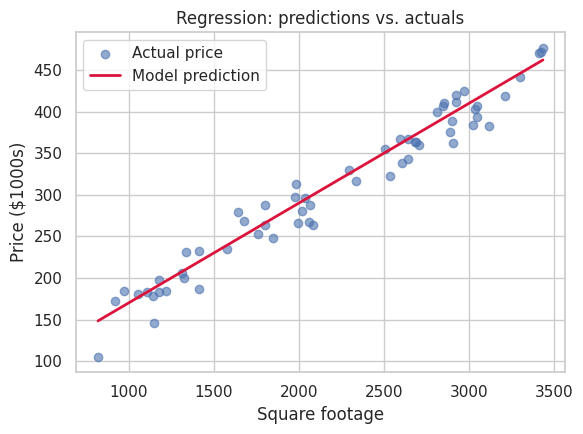

In [10]:
# Synthetic example: predicting house price (in $1000s) from square footage
rng = np.random.default_rng(42)
sqft = rng.uniform(800, 3500, 60)
true_price = 50 + 0.12 * sqft + rng.normal(0, 25, size=60)   # true relationship + noise
predicted_price = 50 + 0.12 * sqft                            # a slightly-off linear model

mae = mean_absolute_error(true_price, predicted_price)
mse = mean_squared_error(true_price, predicted_price)
rmse = np.sqrt(mse)
r2 = r2_score(true_price, predicted_price)

print(f"MAE : ${mae:,.1f}k")
print(f"MSE : {mse:,.1f}")
print(f"RMSE: ${rmse:,.1f}k")
print(f"R^2 : {r2:.3f}")

plt.figure(figsize=(6, 4.5))
plt.scatter(sqft, true_price, alpha=0.6, label="Actual price")
order = np.argsort(sqft)
plt.plot(sqft[order], predicted_price[order], color="crimson", lw=2, label="Model prediction")
plt.xlabel("Square footage")
plt.ylabel("Price ($1000s)")
plt.title("Regression: predictions vs. actuals")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
X1 = 'Square Footage', X2 = 'No.of Rooms', ..., Xn = 'nth feature'
Y = 'Price'

y = 'mx + c'

Y = 'a*X1 + b*X2 + c'

---
## 6. Project — Titanic: Supervised Learning on Messy, Real Data

Iris is clean by design. Real data rarely is. The Titanic dataset — predicting passenger
survival — is the classic next step: it has missing values, mixed data types, and a genuinely
imbalanced target, so every concept above gets exercised for real.

In [11]:
# Titanic dataset via seaborn's bundled copy (no external download needed)
df_titanic = sns.load_dataset("titanic")
df_titanic.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [12]:
print(df_titanic.shape)
df_titanic.isna().sum().sort_values(ascending=False).head(6)


(891, 15)


deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
dtype: int64

**Reasoning — handle missing data before you model.** `age` and `deck` have real gaps.
We *cannot* silently drop every incomplete row (we'd lose ~20% of the data and bias the sample
toward passengers with better records, often correlated with class/fare). Instead we impute:
fill numeric gaps with the median (robust to outliers) and treat missing categoricals as their
own category where appropriate.

In [13]:
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
target = "survived"

data = df_titanic[features + [target]].copy()
data["sex"] = data["sex"].map({"male": 0, "female": 1})
data["embarked"] = data["embarked"].fillna(data["embarked"].mode()[0])
data = pd.get_dummies(data, columns=["embarked"], drop_first=True)

imputer = SimpleImputer(strategy="median")
data["age"] = imputer.fit_transform(data[["age"]])

data.head()


,pclass,sex,age,sibsp,parch,fare,survived,embarked_Q,embarked_S
0,3,0,22.0,1,0,7.2500,0,False,True
1,1,1,38.0,1,0,71.2833,1,False,False
2,3,1,26.0,0,0,7.9250,1,False,True
3,1,1,35.0,1,0,53.1000,1,False,True
4,3,0,35.0,0,0,8.0500,0,False,True


Survival rate overall: 0.384

Survival rate by class:
 pclass
1    0.630
2    0.473
3    0.242
Name: survived, dtype: float64

Survival rate by sex (0=male, 1=female):
 sex
0    0.189
1    0.742
Name: survived, dtype: float64


/tmp/ipykernel_534/4115624363.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Male", "Female"])


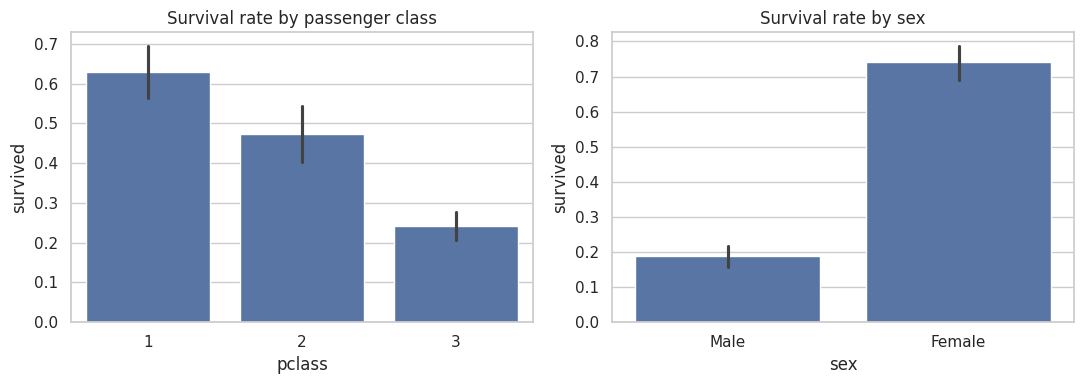

In [14]:
print("Survival rate overall:", round(data["survived"].mean(), 3))
print("\nSurvival rate by class:\n", data.groupby("pclass")["survived"].mean().round(3))
print("\nSurvival rate by sex (0=male, 1=female):\n", data.groupby("sex")["survived"].mean().round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=data, x="pclass", y="survived", ax=axes[0])
axes[0].set_title("Survival rate by passenger class")
sns.barplot(data=data, x="sex", y="survived", ax=axes[1])
axes[1].set_xticklabels(["Male", "Female"])
axes[1].set_title("Survival rate by sex")
plt.tight_layout()
plt.show()


This is exactly why **accuracy alone is dangerous here**: ~62% of passengers did not
survive, so a model that always predicts "did not survive" would already score ~62% accuracy
while being completely useless. Precision, recall, and F1 will tell the real story.

In [15]:
X_t = data.drop(columns=["survived"])
y_t = data["survived"]

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    X_t, y_t, test_size=0.2, random_state=42, stratify=y_t
)

# Scale features: logistic regression's optimiser converges faster and more reliably
# when features share a similar numeric range (fare ranges to 500+, sex is 0/1).
scaler = StandardScaler()
Xt_train_scaled = scaler.fit_transform(Xt_train)
Xt_test_scaled = scaler.transform(Xt_test)   # fit only on train — test must stay "unseen"

titanic_clf = LogisticRegression(max_iter=500)
titanic_clf.fit(Xt_train_scaled, yt_train)
yt_pred = titanic_clf.predict(Xt_test_scaled)

print(f"Baseline (always predict 'did not survive') accuracy: {(1 - yt_test.mean()):.3f}")
print(f"Logistic Regression accuracy: {accuracy_score(yt_test, yt_pred):.3f}")


Baseline (always predict 'did not survive') accuracy: 0.615
Logistic Regression accuracy: 0.804


**Reasoning — why fit the scaler only on training data?** `scaler.fit_transform(X_train)`
learns the mean/std from training data only, then `scaler.transform(X_test)` *applies* those
same statistics to the test set. If we fit the scaler on the full dataset before splitting,
information about the test set's distribution would leak into training — a subtle form of
the same problem the train/test split exists to prevent, sometimes called **data leakage**.

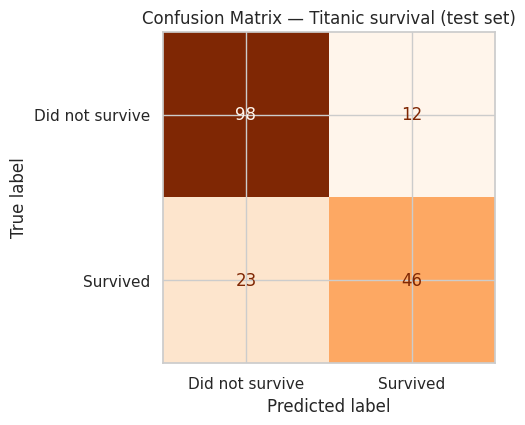

                 precision    recall  f1-score   support

Did not survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



In [16]:
cm_t = confusion_matrix(yt_test, yt_pred)
disp_t = ConfusionMatrixDisplay(confusion_matrix=cm_t, display_labels=["Did not survive", "Survived"])

fig, ax = plt.subplots(figsize=(5, 4.5))
disp_t.plot(ax=ax, cmap="Oranges", colorbar=False)
ax.set_title("Confusion Matrix — Titanic survival (test set)")
plt.tight_layout()
plt.show()

print(classification_report(yt_test, yt_pred, target_names=["Did not survive", "Survived"]))


Compare this classification report to the Iris one: Titanic's classes are imbalanced
and the features are noisier, so precision/recall for the minority behaviour (survival) will
typically be lower than Iris's near-perfect scores. That gap *is* the lesson — clean textbook
data and real-world data behave differently, and the metrics make that difference visible
instead of hiding it behind a single accuracy number.

---
## 7. Unsupervised Learning

### 7.1 The idea

Now remove the labels entirely. Unsupervised learning works with $X$ only — no $y$ — and
tries to discover structure that already exists in the data: groups, patterns, or a simpler
representation.

**Why "unsupervised"?** There's no supervisor telling us the "correct" grouping. The
algorithm must rely purely on the geometry or statistics of the data itself.

### 7.2 The math — K-Means clustering

K-Means partitions $n$ points into $k$ clusters by minimising the total squared distance
between each point and the center (centroid) of the cluster it's assigned to:

$$
\min_{\{\mu_k\}} \sum_{k=1}^{K} \sum_{x_i \in C_k} \lVert x_i - \mu_k \rVert^2
$$

- $\mu_k$ is the centroid (mean position) of cluster $k$.
- $C_k$ is the set of points currently assigned to cluster $k$.
- The algorithm alternates between two steps until convergence:
  1. **Assign** each point to its nearest centroid.
  2. **Update** each centroid to the mean of the points now assigned to it.

**Reasoning — why does this work without labels?** The assumption is that points which are
close together in feature space are more *similar* in whatever real-world sense we care about.
This is weaker than supervised learning's assumption (which requires *labelled* examples of
what "similar" means), so unsupervised methods are cheaper to apply — but the resulting
clusters are only as meaningful as that closeness assumption is, for your specific features.

### 7.3 Real-world example

A retailer with no labelled "customer segments" clusters shoppers by spending score and
income to design targeted promotions — the groups emerge from the data rather than being
predefined.

### 7.4 Demonstration: clustering Iris *without* using the species label

We already know Iris has 3 true species. Let's see how well K-Means — given only the raw
measurements, no labels — rediscovers that structure on its own.

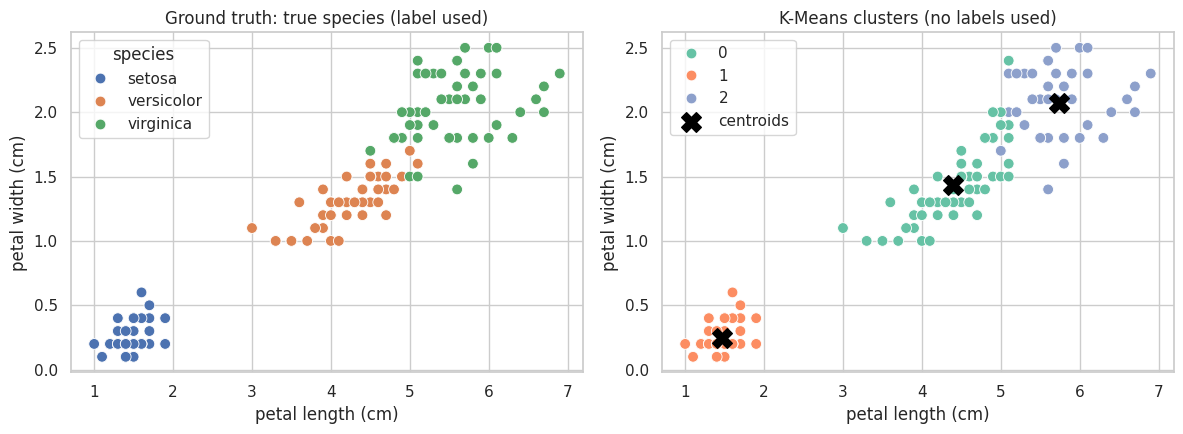

In [17]:
X_unlabeled = df_iris[iris.feature_names].values

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_unlabeled)

df_iris["cluster"] = cluster_labels

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.scatterplot(data=df_iris, x="petal length (cm)", y="petal width (cm)",
                 hue="species", ax=axes[0], s=60)
axes[0].set_title("Ground truth: true species (label used)")

sns.scatterplot(data=df_iris, x="petal length (cm)", y="petal width (cm)",
                 hue="cluster", palette="Set2", ax=axes[1], s=60)
axes[1].scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 3],
                 marker="X", s=200, c="black", label="centroids")
axes[1].set_title("K-Means clusters (no labels used)")
axes[1].legend()

plt.tight_layout()
plt.show()


### 7.5 Evaluating a clustering — no ground truth, so no accuracy

Unsupervised evaluation looks different because there's no "correct answer" to compare against.
The **silhouette score** measures how well-separated the clusters are using geometry alone:

$$
s(i) = \frac{b(i) - a(i)}{\max\big(a(i), b(i)\big)}
$$

where $a(i)$ is the average distance from point $i$ to other points in its *own* cluster, and
$b(i)$ is the average distance to points in the *nearest other* cluster. $s(i)$ ranges from
$-1$ (likely misassigned) to $+1$ (well-clustered); we usually report the mean across all points.

In [18]:
sil_score = silhouette_score(X_unlabeled, cluster_labels)
print(f"Silhouette score: {sil_score:.3f}")

# Since we happen to *have* the true species labels here, we can also sanity-check
# how closely the unsupervised clusters line up with them (not possible in real unsupervised use)
comparison = pd.crosstab(df_iris["species"], df_iris["cluster"])
print("\nCluster vs. true species (for teaching purposes only):")
comparison


Silhouette score: 0.553

Cluster vs. true species (for teaching purposes only):


cluster,0,1,2
species,,,
setosa,0,50,0
versicolor,48,0,2
virginica,14,0,36


The crosstab shows K-Means recovers *setosa* almost perfectly (it's geometrically well
separated) but partially confuses *versicolor* and *virginica*, whose petal measurements
overlap. This is a useful check when labels happen to be available for validation — but note
that in a genuine unsupervised setting, we would never have this crosstab to check against;
the silhouette score above is the kind of metric we'd actually rely on in practice.

---
## 8. Summary — Key Takeaways

1. **Supervised learning** minimises a loss function between predictions and known labels —
   it needs $(x, y)$ pairs, and comes in two flavours: classification (discrete $y$) and
   regression (continuous $y$).
2. **Unsupervised learning** finds structure — like clusters — using only the features $X$,
   with no labels required, by optimising a geometric or statistical objective (e.g. K-Means's
   within-cluster squared distance).
3. **Always evaluate on held-out data.** Train/test split (or k-fold cross-validation) is what
   separates genuine generalisation from memorisation — the gap between train and test error
   tells you whether you're overfitting, underfitting, or doing fine.
4. **Pick metrics that match the problem.** Accuracy can lie on imbalanced data (Titanic);
   precision/recall/F1 tell the real story for classification, while MAE/MSE/RMSE/R² serve the
   same purpose for regression. For clustering, silhouette score fills that role when no ground
   truth exists.

### Next up — Week 5
Linear & Logistic Regression in depth, K-Means, and DBSCAN — using the Boston Housing and
Mall Customers datasets.